# Notebook 4 — Compressed Sensing en 1D con Orthogonal Matching Pursuit (OMP)

## Objetivo

En este notebook se estudia el problema de reconstrucción de señales sparse a partir de un número reducido de medidas lineales, dentro del marco de *Compressed Sensing*.

Los objetivos concretos son los siguientes:

1. construir señales dispersas sintéticas en dimensión finita;
2. adquirir un número de medidas inferior a la dimensión total de la señal;
3. reconstruir la señal a partir de dichas medidas mediante el algoritmo Orthogonal Matching Pursuit (OMP);
4. evaluar cómo influyen en la reconstrucción el número de medidas y el nivel de sparsidad.

Este notebook constituye el primer bloque experimental propiamente centrado en *Compressed Sensing*, ya que muestra de forma explícita que la reconstrucción es posible gracias a la estructura sparse de la señal y no a la disponibilidad de todas sus muestras.

In [ ]:
"""
Quiero demostrar experimentalmente que si una señal es dispersa, puede reconstruirse a partir de menos medidas que su dimensión total
(básicamente la base de mi TFG)

Empiezo con OMP como primer algoritmo porque es intuitivo, visual, se epxlica facil y deja muy claro como se aprovecha la sparsidad

En este cuarto notebook entro ya en compressed sensing de manera explícita. Formulo el problema de reconstrucción sparse a partir de medidas lineales submuestreadas y utilizo
OMP como primer algoritmo de recuperación. Analizo un ejemplo individual, estudio cómo influye el número de medidas y el nivel de sparsidad, y cierro con una estimación 
experimental de la tasa de recuperación exacta del soporte.
"""

'\nQuiero demostrar experimentalmente que si una señal es dispersa, puede reconstruirse a partir de menos medidas que su dimensión total\n(básicamente la base de mi TFG)\n'

## Qué se está haciendo realmente en este notebook

Desde el punto de vista matemático, el problema que se estudia es el siguiente. Sea (escribir la señal que no se hacerlo (ver la señal en mi i pad!!!) una señal sparse. En lugar de observar directamente sus N componentes, se consideran únicamente m medidas lineales:

\[
y = Ax,
\]

donde \xxx y m < N.

En general, este sistema es subdeterminado y no tendría solución única. Sin embargo, si la señal \(x\) es sparse, esa estructura adicional puede aprovecharse para recuperar la solución correcta. En este notebook se utiliza para ello el algoritmo OMP, que selecciona iterativamente las columnas más relevantes del sistema.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Configuración gráfica
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

## 1. Funciones auxiliares

Se definen funciones para:

- generar señales sparse sintéticas;
- construir matrices de medida aleatorias;
- implementar OMP desde cero;
- medir el error de reconstrucción.

In [3]:
def generate_sparse_signal(N, k, seed=None):
    """
    Genera una señal k-sparse de dimensión N.
    """
    rng = np.random.default_rng(seed)
    x = np.zeros(N)

    support = rng.choice(N, size=k, replace=False)
    values = rng.normal(loc=0.0, scale=1.0, size=k)

    x[support] = values
    return x, np.sort(support)


def generate_measurement_matrix(m, N, seed=None):
    """
    Genera una matriz gaussiana aleatoria de tamaño (m, N)
    y normaliza sus columnas.
    """
    rng = np.random.default_rng(seed)
    A = rng.normal(size=(m, N))

    # Normalización de columnas
    norms = np.linalg.norm(A, axis=0)
    norms[norms == 0] = 1.0
    A = A / norms

    return A


def mse(x, x_hat):
    return np.mean((x - x_hat) ** 2)


def relative_error(x, x_hat):
    denom = np.linalg.norm(x)
    if denom == 0:
        return 0.0
    return np.linalg.norm(x - x_hat) / denom

## 2. Implementación de OMP

Orthogonal Matching Pursuit es un algoritmo voraz que reconstruye una señal sparse de manera iterativa.

En cada iteración:

1. calcula qué columna de la matriz de medida está más correlacionada con el residuo actual;
2. añade esa columna al soporte estimado;
3. resuelve un problema de mínimos cuadrados restringido a dicho soporte;
4. actualiza el residuo.

El proceso se repite hasta alcanzar un número máximo de iteraciones o hasta que el residuo sea suficientemente pequeño.

In [4]:
def omp(A, y, k_max, tol=1e-10):
    """
    Orthogonal Matching Pursuit (OMP) implementado desde cero.

    Parámetros
    ----------
    A : ndarray de forma (m, N)
        Matriz de medida.
    y : ndarray de forma (m,)
        Vector de observaciones.
    k_max : int
        Número máximo de iteraciones / sparsidad máxima asumida.
    tol : float
        Tolerancia para detener el algoritmo si el residuo es pequeño.

    Retorna
    -------
    x_hat : ndarray de forma (N,)
        Señal reconstruida.
    support : list
        Índices seleccionados por OMP.
    residual_norms : list
        Norma del residuo en cada iteración.
    """
    m, N = A.shape
    residual = y.copy()
    support = []
    residual_norms = []

    x_hat = np.zeros(N)

    for _ in range(k_max):
        correlations = A.T @ residual
        idx = np.argmax(np.abs(correlations))

        if idx not in support:
            support.append(idx)

        A_support = A[:, support]

        # Resolver mínimos cuadrados restringidos
        coeffs_support, _, _, _ = np.linalg.lstsq(A_support, y, rcond=None)

        # Actualizar estimación completa
        x_hat = np.zeros(N)
        x_hat[support] = coeffs_support

        # Actualizar residuo
        residual = y - A @ x_hat
        residual_norm = np.linalg.norm(residual)
        residual_norms.append(residual_norm)

        if residual_norm < tol:
            break

    return x_hat, support, residual_norms

## Explicación del algoritmo OMP

Orthogonal Matching Pursuit (OMP) es un algoritmo voraz de reconstrucción sparse. Se utiliza cuando se quiere recuperar una señal \(x\) a partir de medidas lineales \(y = Ax\), en un contexto en el que hay menos medidas que incógnitas y, por tanto, el problema no tiene solución única si no se añade información extra.

La idea de OMP es aprovechar que la señal original es dispersa. En cada iteración, el algoritmo busca la columna de la matriz \(A\) que está más correlacionada con el residuo actual, es decir, con la parte de la señal que todavía no ha sido explicada. Esa columna se añade al soporte estimado, y después se resuelve un problema de mínimos cuadrados restringido a las columnas seleccionadas hasta ese momento.

A continuación, se actualiza la reconstrucción y se calcula un nuevo residuo. El proceso se repite varias veces, de modo que el algoritmo va incorporando iterativamente las componentes más relevantes de la señal. OMP funciona bien porque, si la señal es suficientemente sparse y la matriz de medida es adecuada, las columnas correctas tienden a destacar en las correlaciones con el residuo. Por ello, el algoritmo puede identificar el soporte verdadero de la señal y reconstruirla con bastante precisión.

En resumen, OMP reconstruye la señal seleccionando iterativamente las direcciones más relevantes y reajustando en cada paso la mejor combinación lineal posible sobre el soporte elegido. Su interés dentro de *Compressed Sensing* reside en que permite recuperar señales sparse a partir de un número reducido de medidas, explotando directamente su estructura interna.

## 3. Primer experimento: reconstrucción de una señal sparse

Se genera una señal sparse de dimensión \(N\), se adquieren únicamente \(m < N\) medidas lineales y se intenta reconstruir la señal original mediante OMP.

In [5]:
# Parámetros del experimento
N = 128      # dimensión de la señal
k = 8        # nivel de sparsidad
m = 40       # número de medidas (m < N)

# Generación de señal y medidas
x_true, support_true = generate_sparse_signal(N, k, seed=1)
A = generate_measurement_matrix(m, N, seed=2)
y = A @ x_true

print(f"Dimensión N = {N}")
print(f"Sparsidad k = {k}")
print(f"Número de medidas m = {m}")
print(f"Soporte real = {support_true}")

Dimensión N = 128
Sparsidad k = 8
Número de medidas m = 40
Soporte real = [  4  18  57  62  92 104 117 121]


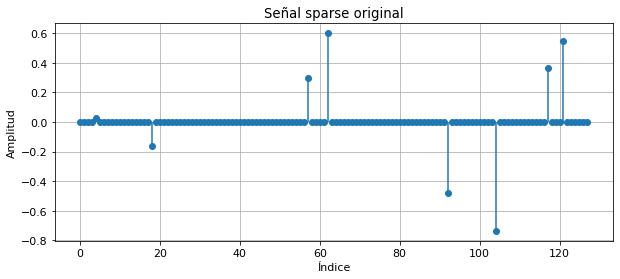

In [6]:
plt.figure()
plt.stem(np.arange(N), x_true, basefmt=" ")
plt.title("Señal sparse original")
plt.xlabel("Índice")
plt.ylabel("Amplitud")
plt.show()

### Comentario

La señal original tiene dimensión 128, pero solo contiene 8 componentes no nulas. Esta es precisamente la estructura sparse que OMP intentará explotar para reconstruirla a partir de únicamente 40 medidas lineales.

In [7]:
x_hat, support_hat, residual_norms = omp(A, y, k_max=k)

mse_value = mse(x_true, x_hat)
rel_value = relative_error(x_true, x_hat)

print(f"Soporte estimado = {np.sort(support_hat)}")
print(f"MSE = {mse_value:.12f}")
print(f"Error relativo = {rel_value:.12e}")

Soporte estimado = [  4  18  57  62  92 104 117 121]
MSE = 0.000000000000
Error relativo = 9.356301736816e-16


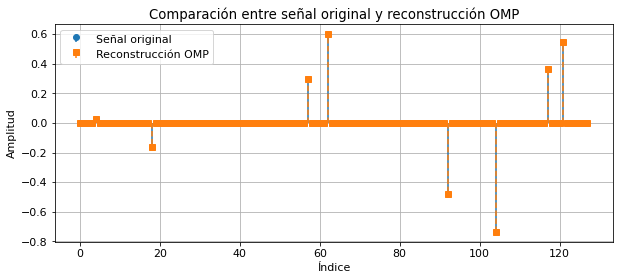

In [8]:
plt.figure()
plt.stem(np.arange(N), x_true, linefmt="C0-", markerfmt="C0o", basefmt=" ", label="Señal original")
plt.stem(np.arange(N), x_hat, linefmt="C1--", markerfmt="C1s", basefmt=" ", label="Reconstrucción OMP")
plt.title("Comparación entre señal original y reconstrucción OMP")
plt.xlabel("Índice")
plt.ylabel("Amplitud")
plt.legend()
plt.show()

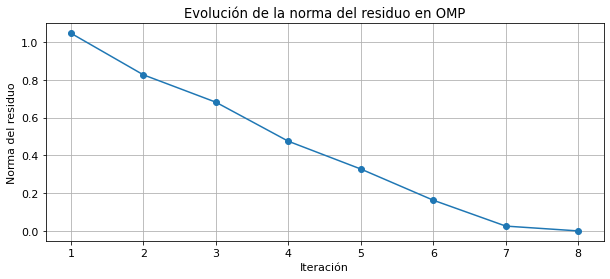

In [9]:
plt.figure()
plt.plot(np.arange(1, len(residual_norms) + 1), residual_norms, marker="o")
plt.title("Evolución de la norma del residuo en OMP")
plt.xlabel("Iteración")
plt.ylabel("Norma del residuo")
plt.show()

### Interpretación

Si la reconstrucción es correcta, la señal estimada coincide con la original y el residuo disminuye rápidamente a medida que OMP selecciona las columnas relevantes. Este comportamiento muestra cómo el algoritmo va identificando de forma iterativa la estructura sparse escondida en los datos observados.

## 4. Influencia del número de medidas

Una de las preguntas más importantes en *Compressed Sensing* es cómo cambia la calidad de la reconstrucción cuando se modifica el número de medidas disponibles.

En este apartado se fija la sparsidad \(k\) y se reconstruye la misma señal usando distintos valores de \(m\).

In [10]:
N = 128
k = 8

x_true, support_true = generate_sparse_signal(N, k, seed=10)

m_values = [16, 24, 32, 40, 48, 64, 80]
results_m = []

for m in m_values:
    A = generate_measurement_matrix(m, N, seed=20 + m)
    y = A @ x_true

    x_hat, support_hat, residual_norms = omp(A, y, k_max=k)

    results_m.append({
        "m": m,
        "mse": mse(x_true, x_hat),
        "relative_error": relative_error(x_true, x_hat),
        "support_recovered": np.array_equal(np.sort(support_true), np.sort(support_hat)),
        "x_hat": x_hat
    })

pd.DataFrame([{k: v for k, v in r.items() if k != "x_hat"} for r in results_m])

,m,mse,relative_error,support_recovered
0,16,1.813828e-02,7.603285e-01,False
1,24,3.513215e-05,3.346229e-02,False
2,32,6.950999e-03,4.706812e-01,False
3,40,4.175694e-32,1.153633e-15,True
4,48,2.013199e-32,8.010259e-16,True
5,64,1.985852e-32,7.955668e-16,True
6,80,6.530257e-32,1.442674e-15,True


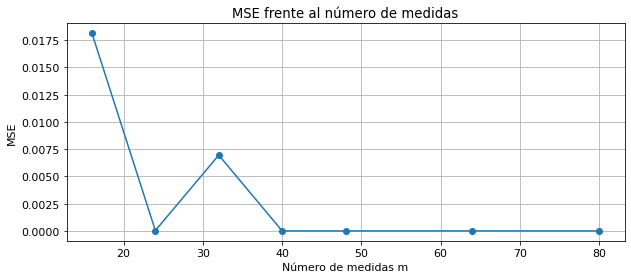

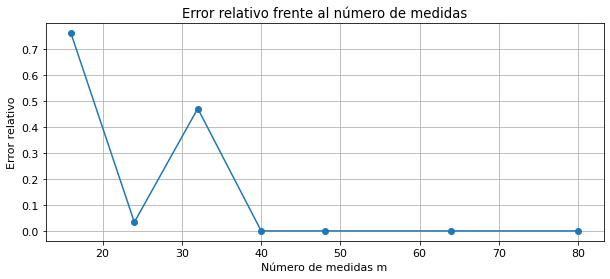

In [11]:
m_list = [r["m"] for r in results_m]
mse_list = [r["mse"] for r in results_m]
rel_list = [r["relative_error"] for r in results_m]

plt.figure()
plt.plot(m_list, mse_list, marker="o")
plt.title("MSE frente al número de medidas")
plt.xlabel("Número de medidas m")
plt.ylabel("MSE")
plt.show()

plt.figure()
plt.plot(m_list, rel_list, marker="o")
plt.title("Error relativo frente al número de medidas")
plt.xlabel("Número de medidas m")
plt.ylabel("Error relativo")
plt.show()

### Interpretación

Se espera que, a medida que aumenta el número de medidas, la reconstrucción mejore y el error disminuya. Este resultado ilustra de forma experimental la relación entre la cantidad de información adquirida y la posibilidad de recuperar correctamente la señal sparse.

## 5. Influencia del nivel de sparsidad

Ahora se fija el número de medidas y se estudia cómo afecta a la reconstrucción el hecho de que la señal sea más o menos sparse.

In [12]:
N = 128
m = 40

k_values = [2, 4, 6, 8, 10, 12, 16]
results_k = []

A = generate_measurement_matrix(m, N, seed=100)

for k in k_values:
    x_true, support_true = generate_sparse_signal(N, k, seed=200 + k)
    y = A @ x_true

    x_hat, support_hat, residual_norms = omp(A, y, k_max=k)

    results_k.append({
        "k": k,
        "mse": mse(x_true, x_hat),
        "relative_error": relative_error(x_true, x_hat),
        "support_recovered": np.array_equal(np.sort(support_true), np.sort(support_hat))
    })

df_k = pd.DataFrame(results_k)
df_k

,k,mse,relative_error,support_recovered
0,2,3.490748e-33,5.774213e-16,True
1,4,1.186027e-33,3.187667e-16,True
2,6,1.218753e-32,4.650719e-16,True
3,8,6.672926e-31,2.453099e-15,True
4,10,8.227899e-03,3.078991e-01,False
5,12,2.583936e-31,1.330278e-15,True
6,16,9.404383e-03,3.431749e-01,False


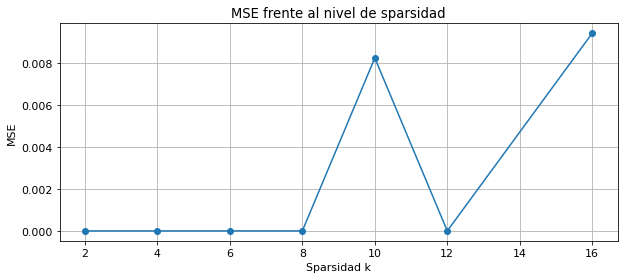

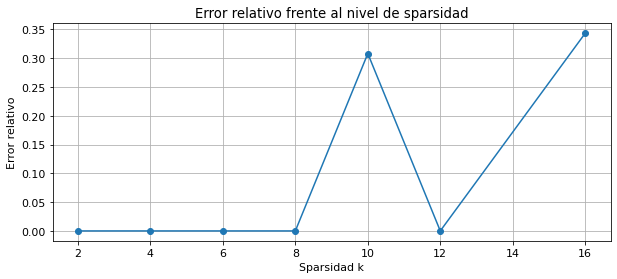

In [13]:
plt.figure()
plt.plot(df_k["k"], df_k["mse"], marker="o")
plt.title("MSE frente al nivel de sparsidad")
plt.xlabel("Sparsidad k")
plt.ylabel("MSE")
plt.show()

plt.figure()
plt.plot(df_k["k"], df_k["relative_error"], marker="o")
plt.title("Error relativo frente al nivel de sparsidad")
plt.xlabel("Sparsidad k")
plt.ylabel("Error relativo")
plt.show()

### Interpretación

Al aumentar la sparsidad \(k\), la señal deja de ser tan simple y el problema de reconstrucción se vuelve más difícil. Para un número fijo de medidas, esto suele traducirse en un empeoramiento progresivo de la calidad de la reconstrucción.

## 6. Tasa de éxito de recuperación

Para obtener una visión más robusta del comportamiento del algoritmo, se repite el experimento varias veces y se estima la tasa de recuperación exacta del soporte para distintos valores de \(m\).

In [14]:
N = 128
k = 8
m_values = [16, 24, 32, 40, 48, 64, 80]
n_trials = 50

success_rates = []

for m in m_values:
    successes = 0

    for trial in range(n_trials):
        x_true, support_true = generate_sparse_signal(N, k, seed=1000 + trial + 10*m)
        A = generate_measurement_matrix(m, N, seed=2000 + trial + 10*m)
        y = A @ x_true

        x_hat, support_hat, _ = omp(A, y, k_max=k)

        if np.array_equal(np.sort(support_true), np.sort(support_hat)):
            successes += 1

    success_rate = successes / n_trials
    success_rates.append(success_rate)

df_success = pd.DataFrame({
    "m": m_values,
    "success_rate": success_rates
})
df_success

,m,success_rate
0,16,0.02
1,24,0.40
2,32,0.80
3,40,0.94
4,48,0.96
5,64,1.00
6,80,1.00


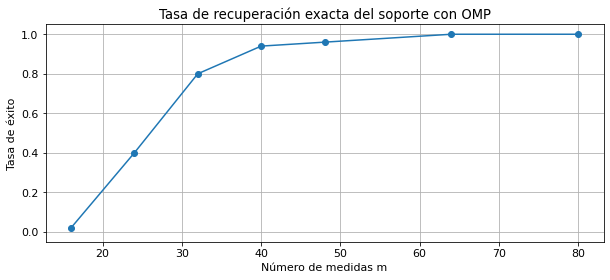

In [15]:
plt.figure()
plt.plot(m_values, success_rates, marker="o")
plt.title("Tasa de recuperación exacta del soporte con OMP")
plt.xlabel("Número de medidas m")
plt.ylabel("Tasa de éxito")
plt.ylim(-0.05, 1.05)
plt.show()

### Interpretación

La tasa de éxito permite ir más allá de un único ejemplo concreto y proporciona una medida experimental de la robustez del algoritmo. En general, al aumentar el número de medidas, la probabilidad de recuperar exactamente el soporte correcto crece de manera significativa.

## 7. Conclusiones del notebook

Los experimentos realizados en este notebook permiten extraer las siguientes conclusiones:

1. una señal sparse puede reconstruirse a partir de un número de medidas inferior a su dimensión total;
2. el algoritmo OMP recupera la señal mediante una selección iterativa de las columnas más relevantes;
3. la calidad de la reconstrucción mejora al aumentar el número de medidas disponibles;
4. para un número fijo de medidas, el problema se vuelve más difícil cuando la señal es menos sparse;
5. la recuperación exacta del soporte puede estudiarse experimentalmente mediante tasas de éxito.

Este notebook constituye la primera validación directa del paradigma de *Compressed Sensing* en un caso sintético controlado. A partir de aquí, el siguiente paso natural consiste en estudiar algoritmos basados en optimización \(\ell_1\), como ISTA y FISTA, y comparar su comportamiento con el de OMP.